<a href="https://colab.research.google.com/github/Assma-IBIKAS/Assma-IBIKAS/blob/main/Pr%C3%A9vision_de_la_Demande_%C3%89nerg%C3%A9tique_pour_Smart_Grid_via_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importation des biblios nécessaires ...

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 694.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
from google.colab import files
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


##Charger dataset

In [ ]:
uploaded = files.upload()

Saving data_smart_grid.csv to data_smart_grid.csv


##Lire dataset

In [ ]:
df = pd.read_csv("data_smart_grid.csv")
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


##Afficher les colonnes de dataset

In [ ]:
print("Colonnes utilisées :", df.columns.tolist())

Colonnes utilisées : ['DateTime', 'Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']


1- **Pourquoi l’ordre temporel est critique**
- réponse : Parce que les données sont une série temporelle : ce qui se passe à t dépend de ce qui s'est passé avant (t-1, t-2...). Si on mélange l'ordre, le modèle ne peut plus apprendre les patterns dans le temps.

2- **Pourquoi on ne mélange pas les données (pas de shuffle)**
- réponse : Mélanger détruit l'ordre du temps. Le modèle apprendrait des relations fausses, comme si le futur influençait le passé.

In [ ]:
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values("DateTime")
df.set_index("DateTime", inplace=True)
df.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


3- **Pourquoi la normalisation est indispensable en Deep Learning**
- réponse : Les valeurs brutes peuvent être très différentes (ex: une colonne en milliers, une autre en unités). Sans normalisation, l'entraînement est lent et instable, car les gradients deviennent trop grands ou trop petits.

4- **Pourquoi MinMax est souvent préféré à StandardScaler pour LSTM**
- réponse : MinMax met tout entre 0 et 1 (ou -1 et 1), ce qui va bien avec les activations comme sigmoid ou tanh dans les LSTM. StandardScaler peut donner des valeurs négatives, ce qui est moins bon pour ces activations.

In [ ]:
# On utilise MinMaxScaler pour compresser les valeurs entre 0 et 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

5- **Pourquoi un LSTM attend des données en 3D**
- réponse :Parce que LSTM traite des séquences. Il a besoin de voir plusieurs pas de temps à la fois.

6- **Signification de la forme : (samples, timesteps, features)**
- réponse :
  - ***samples*** : nombre d'exemples (séquences)
  - ***timesteps*** : longueur de la fenêtre (ici 24 heures)
  - ***features*** : nombre de variables à chaque heure (consumption + toutes les productions)

In [ ]:
# Création des séquences (Windowing)
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        # X contient les 24h précédentes (toutes les colonnes)
        X.append(data[i-window:i])
        # y contient la consommation à l'heure suivante (index 0 : 'Consumption')
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Fenêtre de 24 heures pour prédire l'heure t+1
X, y = create_sequences(scaled_data, window=24)

7- **Pourquoi on ne fait pas de train_test_split classique**
- réponse : Le split classique mélange aléatoirement. Ça cause une fuite de données : le modèle verrait du futur pendant l'entraînement.

8- **Risque de fuite de données temporelles**
- réponse : Si on mélange, le train peut contenir des données après le test. Le modèle "connaît" le futur, et les résultats sont trop bons mais faux en réalité.

In [ ]:
# Split Train / Test (80% entraînement, 20% test)
# On ne mélange pas les données pour respecter l'ordre chronologique
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

9- **Impact du nombre d’unités LSTM**
- réponse : Plus d'unités (ex: 64 au lieu de 32) = plus de capacité à apprendre des patterns complexes. Mais trop = risque de surapprentissage et plus long à entraîner.

10- **Différence entre 1 ou plusieurs couches LSTM**
- réponse :
  - *Une seule couche* : simple, apprend des patterns basiques.
  - *Plusieurs couches (stacked)* : chaque couche apprend sur les sorties de la précédente, capture des patterns plus abstraits et complexes. Mais plus risqué pour le surapprentissage.

In [ ]:
# Architecture du modèle LSTM
model = Sequential([
    # Input_shape : (24 timesteps, nombre de colonnes)
    LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dropout(0.2), # Pour éviter le surapprentissage
    Dense(32, activation='relu'),
    Dense(1) # Sortie unique : la consommation à t+1
])

model.compile(optimizer="adam", loss="mse")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11- **Courbe loss vs val_loss**
- réponse :
  - *Les deux baissent*: bon apprentissage.
  - *Train loss continue à baisser mais val_loss monte* : surapprentissage (le modèle mémorise le train au lieu de généraliser).

12- **Détection du surapprentissage**
- réponse : Quand val_loss arrête de baisser et commence à augmenter, tandis que train loss baisse encore. Il y a un écart qui grandit entre les deux courbes.

In [ ]:
# Entraînement avec monitoring
history = model.fit(
    X_train, y_train,
    validation_split=0.1, # On garde 10% du train pour la validation
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0151 - val_loss: 0.0034
Epoch 2/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 3/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 4/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.3820e-04 - val_loss: 0.0026
Epoch 5/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 7.2292e-04 - val_loss: 0.0032
Epoch 6/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.4255e-04 - val_loss: 0.0037
Epoch 7/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.8511e-04 - val_loss: 0.0030
Epoch 8/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.4088e-04 - val_loss: 0.0036
Epoch 9/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.2744e-04 - val_loss: 0.0033
Epoch 10/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4.8863e-04 - val_loss: 0.0032
Epoch 11/30
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 4.6284e-04 - val_loss: 0.003

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


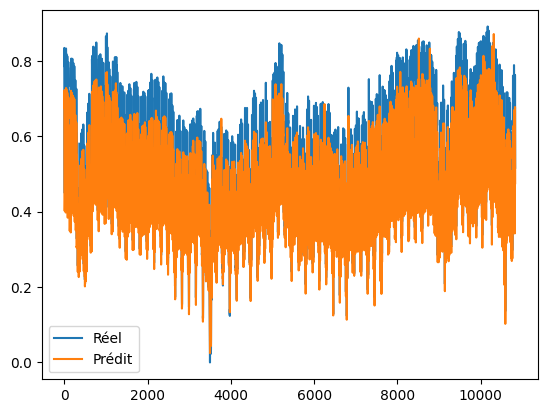

In [ ]:
y_pred = model.predict(X_test)
plt.plot(y_test, label="Réel")
plt.plot(y_pred, label="Prédit")
plt.legend()
plt.show()